<a href="https://colab.research.google.com/github/rylan-berry/DataScienceExercises2025-2026/blob/main/Rylan's_Copy_of_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

*A polynomial can fit a more complex trend, increasing acuracy of a prediction.*

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

*If a trend isn't that complex to begin with, a polynomial would attempt to overfit the data, which wouldn't be great.*

**Task3**:

What's the point of using b splines?

*A b spline is similar to making a higher and higher degree polynomial, you're trying to match a trend that can be different over any given section. So a b spline will split up the data and predict over the sections, then combine it back together for a complete prediction.*

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

*A Gaussian Process is like a b spline with infinetly many sections. It's trying to find association between each datapoint, and how that'd effect the final prediction.*

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install bambi
import bambi as bmb

!pip install preliz
import preliz as pz

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator

In [ ]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


Text(0, 0.5, 'w')

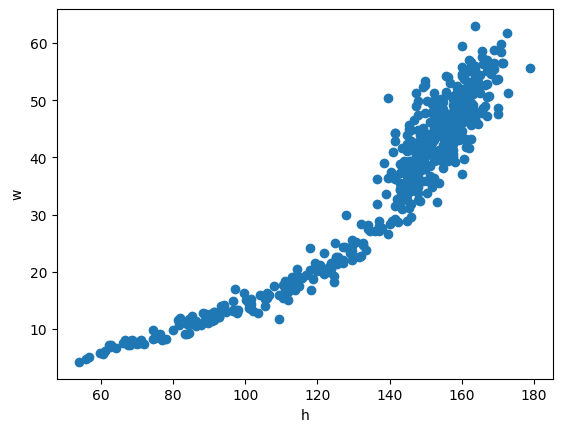

In [ ]:
plt.scatter(howell['height'] , howell['weight'],)

#label axes
plt.xlabel("h")
plt.ylabel("w")

In [ ]:
#Unit 5 final model
with pm.Model() as model_glhvw2:

    α = pm.Normal("α", sigma=20)
    β = pm.Normal("β", sigma=10)
    c = pm.Normal("c", sigma=20)

    #priors for the line for our standard deviation
    γ = pm.HalfNormal("γ", sigma=20)
    δ = pm.HalfNormal("δ", sigma=10)
    j = pm.HalfNormal("j", sigma=20)

    #mean line
    μ = pm.Deterministic("μ", α + β * (howell.height)**2 + c * howell.height)

    #standard deviation line; this allows our variance to vary over th x values
    σ = pm.Deterministic("σ", γ + δ * (howell.height)**2 + j * howell.height)

    #normal likelihood
    y_pred = pm.Normal("y_pred", mu=μ, sigma=σ, observed=howell.weight)

    idata_glhvw2 = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_glhvw2, model=model_glhvw2,  extend_inferencedata=True)

Text(0, 0.5, 'weight')

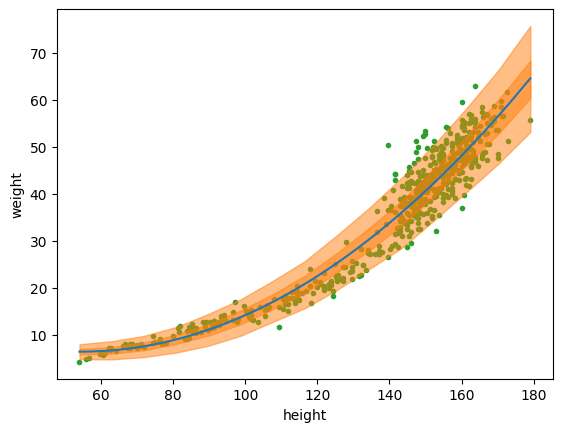

In [ ]:
mean_line = idata_glhvw2.posterior["μ"].mean(("chain", "draw"))
height = np.random.normal(howell.height.values, 0.01)
idx = np.argsort(height)
x = np.linspace(height.min(), height.max(), 15)
y_pred_q = idata_glhvw2.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        PchipInterpolator(height[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)
_, ax = plt.subplots()
ax.plot(howell.height, howell.weight, "C2.", zorder=-3)
ax.plot(howell.height[idx], mean_line[idx], c="C0")
for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)
ax.set_xlabel("height")
ax.set_ylabel("weight")

<Axes: xlabel='y_pred'>

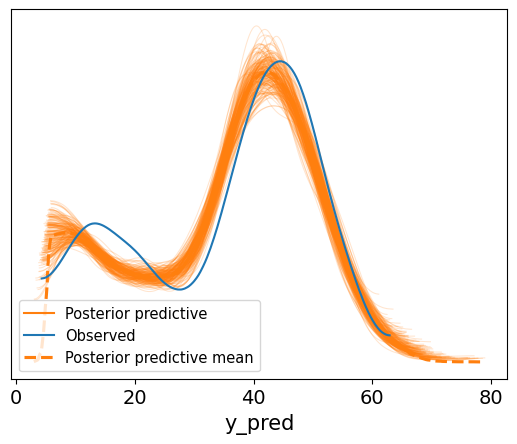

In [ ]:
az.plot_ppc(idata_glhvw2, num_pp_samples=200, colors=["C1", "C0", "C1"])

In [ ]:
#Polynomial
model_poly = bmb.Model("weight ~ poly(height, degree=3)", howell, family="negativebinomial")
idata_poly = model_poly.fit()

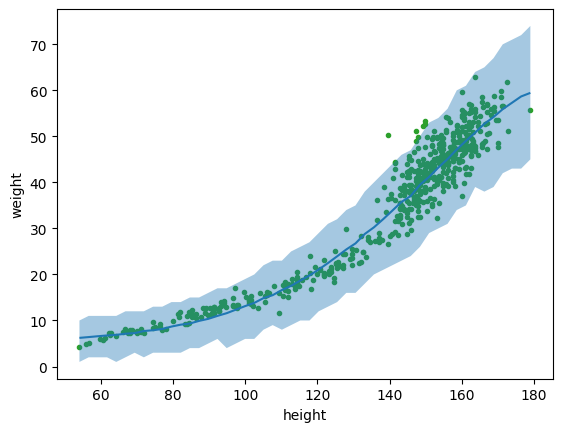

In [ ]:
bmb.interpret.plot_predictions(model_poly, idata_poly, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
#B-Spline
num_knots = 3
knots = np.linspace(54, 185, num_knots+2)[1:-1]
model_spline_t = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline_t = model_spline_t.fit()

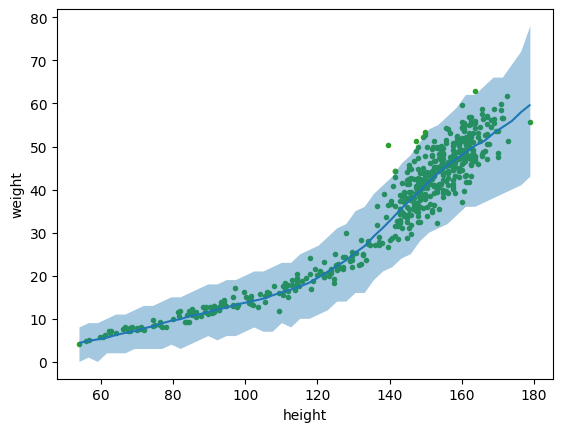

In [ ]:
bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
weight = howell["weight"].values
height = howell["height"].values[:,None]

In [ ]:
#HSGP

#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))


prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}
priors = {
    "hsgp(hour, m=128, c=4.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}
model_hsgp = bmb.Model("weight ~ 0 + hsgp(height, m=128, c=4.0)", howell, priors=priors)
idata_hsgp = model_hsgp.fit()

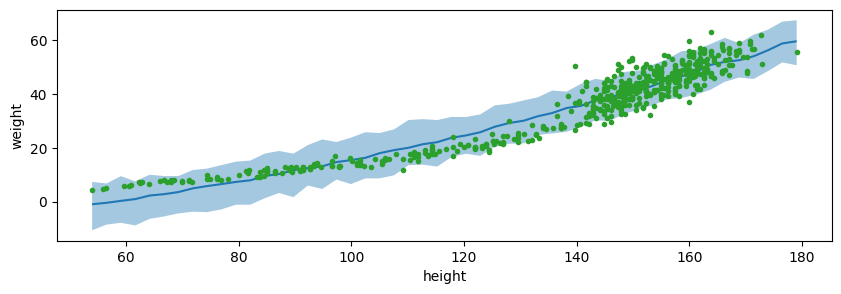

In [ ]:
_, ax = bmb.interpret.plot_predictions(model_hsgp, idata_hsgp, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

In [ ]:
#HSGP

#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))


prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}
priors = {
    "hsgp(hour, m=200, c=4.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}
model_hsgp = bmb.Model("weight ~ 0 + hsgp(height, m=200, c=4.0)", howell, priors=priors)
idata_hsgp = model_hsgp.fit()

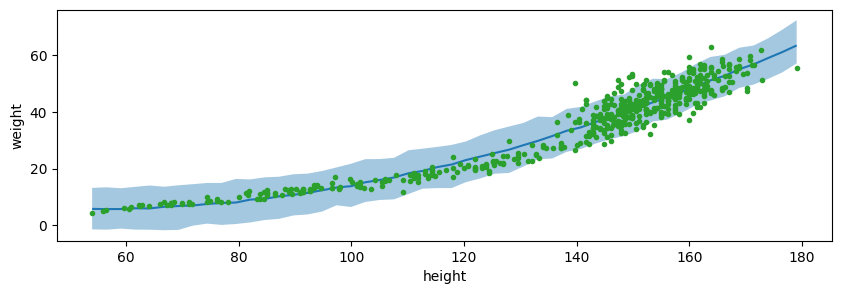

In [ ]:
_, ax = bmb.interpret.plot_predictions(model_hsgp, idata_hsgp, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

In [ ]:
#HSGP

#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))


prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}
priors = {
    "hsgp(hour, m=128, c=2.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}
model_hsgp = bmb.Model("weight ~ 0 + hsgp(height, m=128, c=2.0)", howell, priors=priors)
idata_hsgp = model_hsgp.fit()

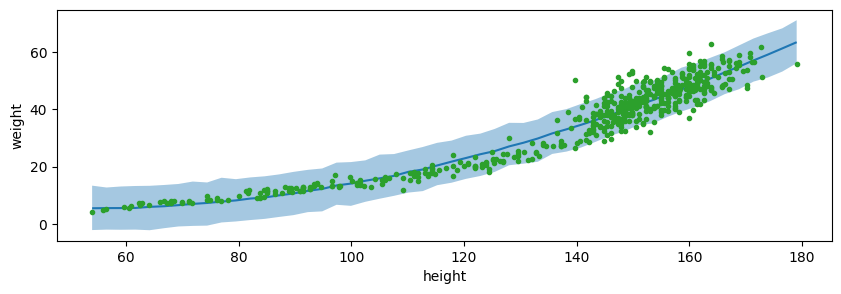

In [ ]:
_, ax = bmb.interpret.plot_predictions(model_hsgp, idata_hsgp, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

*I learned that if you use different datasets with different collection methods and science behind them you need to find a way to make them consistant. Which the author of this article did by adding variance to the definite dataset to match the past uncertain data.*

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

*My favorite graph is the heatmap under the "A gradual change with a sigmoid function" section. Visually speaking, the slope of the heat map looks negative, but if you look at the y axis the numbers are decreasing as you go up, so it's really a positive slope. Another thing with the heatmap is that the "temp" is higher at lower x values, and lower at greater x values.*

*Now, the real question: why is it my favorite? Well it's really simple. It just looks cool man, heat maps are always really nice to look at.*